# 🏥 StayWise: Hospital Length of Stay Prediction

## 1. Project Overview
Hospital length of stay (LOS) is one of the most important indicators of hospital efficiency and patient care. Accurate prediction helps hospitals plan beds, staff, and resources, and helps identify patients who may need extra attention.

This notebook builds a machine learning pipeline that predicts how many days a patient will stay in the hospital based on their diagnoses, lab results, and vital signs.

## 2. Objective
Predict lengthofstay (in days), a regression problem.

## 3. Dataset
- Size: 100,000 patient records
- Target: lengthofstay (1 to 17 days)
- Features: demographic, diagnosis, laboratory, and vital sign variables

| Group | Features |
|---|---|
| Demographics | gender |
| Diagnoses (0/1) | dialysisrenalendstage, asthma, irondef, pneum, substancedependence, psychologicaldisordermajor, depress, psychother, fibrosisandother, malnutrition, hemo |
| Laboratory | hematocrit, neutrophils, sodium, glucose, bloodureanitro, creatinine |
| Vital signs | bmi, pulse, respiration |
| History | rcount (readmissions in the last 180 days), secondarydiagnosisnonicd9 |

## 4. Workflow
1. Data loading and exploration
2. Data cleaning (invalid values, missing values, outliers)
3. Feature engineering (e.g., comorb_count, the number of comorbid conditions)
4. Preprocessing (encoding and scaling)
5. Model training and evaluation
6. Deployment as a Streamlit web app

## 5. Libraries
pandas · numpy · matplotlib · scikit-learn · streamlit

In [1]:
# 🛠️ Advanced imports for production ML

# Suppress warnings for cleaner outputs
import warnings
warnings.filterwarnings('ignore')

# 🔧 Core Python libraries
import numpy as np           # Efficient numerical computations
import pandas as pd          # Data manipulation and analysis
import matplotlib.pyplot as plt  # Basic plotting
import seaborn as sns        # Advanced visualization
from scipy import stats      # Statistical functions
import joblib               # Save/load large models and preprocessing objects
import json                 # Handle JSON configs and outputs
from datetime import datetime  # Timestamping for logs
import os                   # File system operations
import time                 # Time tracking for experiments

# 🧰 Sklearn libraries - expanded for advanced ML workflows

from sklearn.model_selection import (
    train_test_split,     # Split data into train/test sets
    cross_val_score,      # Cross-validation scoring
    GridSearchCV,         # Hyperparameter tuning (grid search)
    RandomizedSearchCV    # Hyperparameter tuning (randomized search)
)
from sklearn.preprocessing import (
    StandardScaler,       # Feature scaling (zero-mean, unit variance)
    RobustScaler,         # Scaling robust to outliers
    PolynomialFeatures    # Generate polynomial features for non-linear relationships
)
from sklearn.pipeline import Pipeline, FeatureUnion  # Build modular pipelines
from sklearn.compose import ColumnTransformer         # Apply different preprocessing to columns
from sklearn.feature_selection import (
    SelectKBest,          # Univariate feature selection
    f_regression,         # Scoring function for regression
    RFE                   # Recursive feature elimination
)
from sklearn.linear_model import (
    LinearRegression,     # Baseline regression
    Ridge,                # L2-regularized regression
    Lasso,                # L1-regularized regression
    ElasticNet            # Combination of L1 and L2 regularization
)
from sklearn.ensemble import (
    RandomForestRegressor,       # Ensemble of decision trees
    GradientBoostingRegressor,   # Boosted trees for regression
    VotingRegressor              # Combine multiple regressors
)
from sklearn.svm import SVR               # Support Vector Regression
from sklearn.metrics import (
    mean_squared_error,  # Regression metric
    r2_score,            # Regression metric
    mean_absolute_error  # Regression metric
)
from sklearn.inspection import (
    permutation_importance,       # Feature importance
    PartialDependenceDisplay      # Partial dependence plots
)

# 🧪 Advanced model tracking with MLflow
import mlflow                  # Experiment tracking
import mlflow.sklearn          # Log sklearn models
from mlflow.models.signature import infer_signature  # Auto-capture input/output schema for reproducible deployment


# 🎛️ Configuration & Reproducibility

Before we start modeling, it’s crucial to **establish reproducible and scalable experiment settings**. This ensures that results are consistent, experiments are traceable, and your workflow is production-ready.

### Key Components:

1. **Reproducibility**
   - `RANDOM_STATE = 42`: Ensures that every run produces the same train/test splits, random sampling, and model results.
   - `TEST_SIZE = 0.2`: Reserves 20% of the data for final evaluation.
   - `VAL_SIZE = 0.2`: Reserves a portion of the training data for validation and hyperparameter tuning.
   - `CV_FOLDS = 5`: Use 5-fold cross-validation to evaluate models robustly.
   - `N_JOBS = -1`: Utilizes all available CPU cores to speed up computations.

2. **Organized Project Structure**
   - `MODEL_DIR = "models"`: All trained models are stored in a dedicated folder.
   - `EXPERIMENT_DIR = "experiments"`: All MLflow experiment logs, metrics, and artifacts are saved in a centralized location.
   - `os.makedirs(..., exist_ok=True)`: Ensures directories exist, preventing file errors during training or logging.

3. **MLflow Experiment Tracking**
   - `mlflow.set_tracking_uri(...)` points MLflow to the experiment folder.
   - `mlflow.set_experiment(experiment_name)` creates a named experiment for this project.
   - This allows you to **log models, metrics, and hyperparameters**, enabling easy comparison across experiments.

> 💡 **Pro Tip:** Proper configuration and tracking is like laying the foundation of a building—everything built on top will be reliable, reproducible, and easy to maintain.


In [2]:
class Config:
    # Reproducibility - Critical for production!
    RANDOM_STATE = 42
    TEST_SIZE = 0.2
    VAL_SIZE = 0.2  # NEW: Validation set for tuning
    CV_FOLDS = 5
    N_JOBS = -1  # Use all available cores
    
    # Model directories - Organized project structure
    MODEL_DIR = "models"
    EXPERIMENT_DIR = "experiments"
    
    # Create directories if they don't exist
    os.makedirs(MODEL_DIR, exist_ok=True)
    os.makedirs(EXPERIMENT_DIR, exist_ok=True)

config = Config()

#SQlite database inside experiment folder
db_path = os.path.abspath(os.path.join(config.EXPERIMENT_DIR,"mlflow.db"))
# Initialize MLflow for experiment tracking
mlflow.set_tracking_uri(f"sqlite:///{db_path.replace(os.sep, '/')}")
experiment_name = "Length of stay in hospital"
mlflow.set_experiment(experiment_name = experiment_name)

<Experiment: artifact_location='file:c:/Users/hp/projects/SAIR/mlruns/1', creation_time=1791284453457, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1791284453457, lifecycle_stage='active', name='Length of stay in hospital', tags={}, trace_location=None, workspace='default'>

# loading data

In [3]:
df = pd.read_csv("LengthOfStay3.csv")
print("the first 5 row")
df.head(5)

the first 5 row


,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,depress,psychother,...,neutrophils,sodium,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,lengthofstay
0,0,F,0,0,0,0,0,0,0,0,...,14.20,140.361132,192.476918,12.0,1.390722,30.432418,96,6.5,4,3
1,5,F,0,0,0,0,0,0,0,0,...,4.10,136.731692,94.078507,8.0,0.943164,28.460516,61,6.5,1,7
2,1,F,0,0,0,0,0,0,0,0,...,8.90,133.058514,130.530524,12.0,1.065750,28.843812,64,6.5,2,3
3,0,F,0,0,0,0,0,0,0,0,...,9.40,138.994023,163.377028,12.0,0.906862,27.959007,76,6.5,1,1
4,0,F,0,0,0,1,0,1,0,0,...,9.05,138.634836,94.886654,11.5,1.242854,30.258927,67,5.6,2,4


specify the features and target name

## 🔍 Step 2: Exploratory Data Analysis (EDA)

Before building models, we must **understand our data**:
- Check for missing values
- Understand distributions
- Detect outliers
- Explore relationships between features

In [4]:

# Basic statistics
print("=" * 70)
print("📊 DATASET STATISTICS")
print("=" * 70)
print(df.describe())

📊 DATASET STATISTICS
              rcount  dialysisrenalendstage         asthma        irondef  \
count  100000.000000          100000.000000  100000.000000  100000.000000   
mean        1.118210               0.036420       0.035270       0.094940   
std         1.542958               0.187334       0.184462       0.293134   
min         0.000000               0.000000       0.000000       0.000000   
25%         0.000000               0.000000       0.000000       0.000000   
50%         0.000000               0.000000       0.000000       0.000000   
75%         2.000000               0.000000       0.000000       0.000000   
max         5.000000               1.000000       1.000000       1.000000   

               pneum  substancedependence  psychologicaldisordermajor  \
count  100000.000000        100000.000000               100000.000000   
mean        0.039450             0.063060                    0.239040   
std         0.194664             0.243072                    0.426

# Check the feature data type

In [5]:
# Data types
print("\n" + "=" * 70)
print("📋 DATA TYPES")
print("=" * 70)
print(df.dtypes)


📋 DATA TYPES
rcount                          int64
gender                            str
dialysisrenalendstage           int64
asthma                          int64
irondef                         int64
pneum                           int64
substancedependence             int64
psychologicaldisordermajor      int64
depress                         int64
psychother                      int64
fibrosisandother                int64
malnutrition                    int64
hemo                            int64
hematocrit                    float64
neutrophils                   float64
sodium                        float64
glucose                       float64
bloodureanitro                float64
creatinine                    float64
bmi                           float64
pulse                           int64
respiration                   float64
secondarydiagnosisnonicd9       int64
lengthofstay                    int64
dtype: object


## 📋 Why Checking Data Types Matters

Before building models, it’s crucial to understand the **data types** of each feature.

### ✅ Key Points:
1. **Model Compatibility:**  
   - Most ML models require **numerical input** (float or int).  
   - Categorical features must be encoded (e.g., one-hot or label encoding).

2. **Memory & Performance:**  
   - Correct data types save memory and improve computation speed.

3. **Data Cleaning & Transformation:**  
   - Knowing types helps decide preprocessing steps:
     - Scaling numerical features
     - Encoding categorical variables
     - Handling dates or strings

### 🧪 Next Step

- `sklearn.preprocessing` tools like `OneHotEncoder` and `ColumnTransformer`
- Ensuring the dataset is **ready for modeling**



In [6]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

print("📌 shape of Sample data with a categorical column:")
print(df.shape)
print("📌 Sample data with a categorical column:")
df.head()

# Detect categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

print("\nCategorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

# Preprocessing with ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_cols),
        ('cat', OneHotEncoder(sparse_output=False, drop='first'), categorical_cols)
    ]
)

# Transform the dataset
df_prepared = pd.DataFrame(preprocessor.fit_transform(df), columns=preprocessor.get_feature_names_out())
print("\n✅ Dataset ready for modeling:")
print("Shape after encoding:", df_prepared.shape)
df_prepared.head()


📌 shape of Sample data with a categorical column:
(100000, 24)
📌 Sample data with a categorical column:

Categorical columns: ['gender']
Numeric columns: ['rcount', 'dialysisrenalendstage', 'asthma', 'irondef', 'pneum', 'substancedependence', 'psychologicaldisordermajor', 'depress', 'psychother', 'fibrosisandother', 'malnutrition', 'hemo', 'hematocrit', 'neutrophils', 'sodium', 'glucose', 'bloodureanitro', 'creatinine', 'bmi', 'pulse', 'respiration', 'secondarydiagnosisnonicd9', 'lengthofstay']

✅ Dataset ready for modeling:
Shape after encoding: (100000, 24)


,num__rcount,num__dialysisrenalendstage,num__asthma,num__irondef,num__pneum,num__substancedependence,num__psychologicaldisordermajor,num__depress,num__psychother,num__fibrosisandother,...,num__sodium,num__glucose,num__bloodureanitro,num__creatinine,num__bmi,num__pulse,num__respiration,num__secondarydiagnosisnonicd9,num__lengthofstay,cat__gender_M
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,140.361132,192.476918,12.0,1.390722,30.432418,96.0,6.5,4.0,3.0,0.0
1,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,136.731692,94.078507,8.0,0.943164,28.460516,61.0,6.5,1.0,7.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,133.058514,130.530524,12.0,1.065750,28.843812,64.0,6.5,2.0,3.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,138.994023,163.377028,12.0,0.906862,27.959007,76.0,6.5,1.0,1.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,138.634836,94.886654,11.5,1.242854,30.258927,67.0,5.6,2.0,4.0,0.0


# Chech for null values

In [7]:
# Missing values check
print("\n" + "=" * 70)
print("🔍 MISSING VALUES CHECK")
print("=" * 70)
print(df_prepared.isnull().sum())


🔍 MISSING VALUES CHECK
num__rcount                        0
num__dialysisrenalendstage         0
num__asthma                        0
num__irondef                       0
num__pneum                         0
num__substancedependence           0
num__psychologicaldisordermajor    0
num__depress                       0
num__psychother                    0
num__fibrosisandother              0
num__malnutrition                  0
num__hemo                          0
num__hematocrit                    0
num__neutrophils                   0
num__sodium                        0
num__glucose                       0
num__bloodureanitro                0
num__creatinine                    0
num__bmi                           3
num__pulse                         0
num__respiration                   0
num__secondarydiagnosisnonicd9     0
num__lengthofstay                  0
cat__gender_M                      0
dtype: int64


## 🔍 Why Missing Values Matter

Before training any model, it’s crucial to check for **missing values** in your dataset.

### ✅ Why this matters:
1. **Data Integrity:** Missing values can distort statistics like mean, variance, and correlations.
2. **Model Behavior:**  
   - Some models (like **Linear Regression**, **SVM**, **Logistic Regression**) **cannot handle missing values** natively — they will throw errors.  
   - Other models (like **XGBoost** or some **tree-based algorithms**) can handle missing values internally.
3. **Impact on Performance:** Even a few missing values can **bias your model** or reduce predictive performance.

### 🧪 Next Step
We will demonstrate a **practical approach using `sklearn`** to handle missing values so our models can train safely:

- Impute missing values (mean, median, or most frequent)
- Use sklearn’s `SimpleImputer` for pipeline integration



In [8]:
from sklearn.impute import SimpleImputer
import numpy as np


# Initialize SimpleImputer
imputer = SimpleImputer(strategy='mean')  # You can also use 'median' or 'most_frequent'

# Fit on data and transform
df_imputed = pd.DataFrame(imputer.fit_transform(df_prepared), columns=df_prepared.columns)

print("\n✅ Missing values handled:")
print(df_imputed.isnull().sum()) 



✅ Missing values handled:
num__rcount                        0
num__dialysisrenalendstage         0
num__asthma                        0
num__irondef                       0
num__pneum                         0
num__substancedependence           0
num__psychologicaldisordermajor    0
num__depress                       0
num__psychother                    0
num__fibrosisandother              0
num__malnutrition                  0
num__hemo                          0
num__hematocrit                    0
num__neutrophils                   0
num__sodium                        0
num__glucose                       0
num__bloodureanitro                0
num__creatinine                    0
num__bmi                           0
num__pulse                         0
num__respiration                   0
num__secondarydiagnosisnonicd9     0
num__lengthofstay                  0
cat__gender_M                      0
dtype: int64


📊 Distribution Analysis
Understanding feature distributions helps us:

- Identify data skewness and outliers

- Guide preprocessing decisions (scaling, transformations)

- Understand the nature of each feature

- Detect potential data quality issues

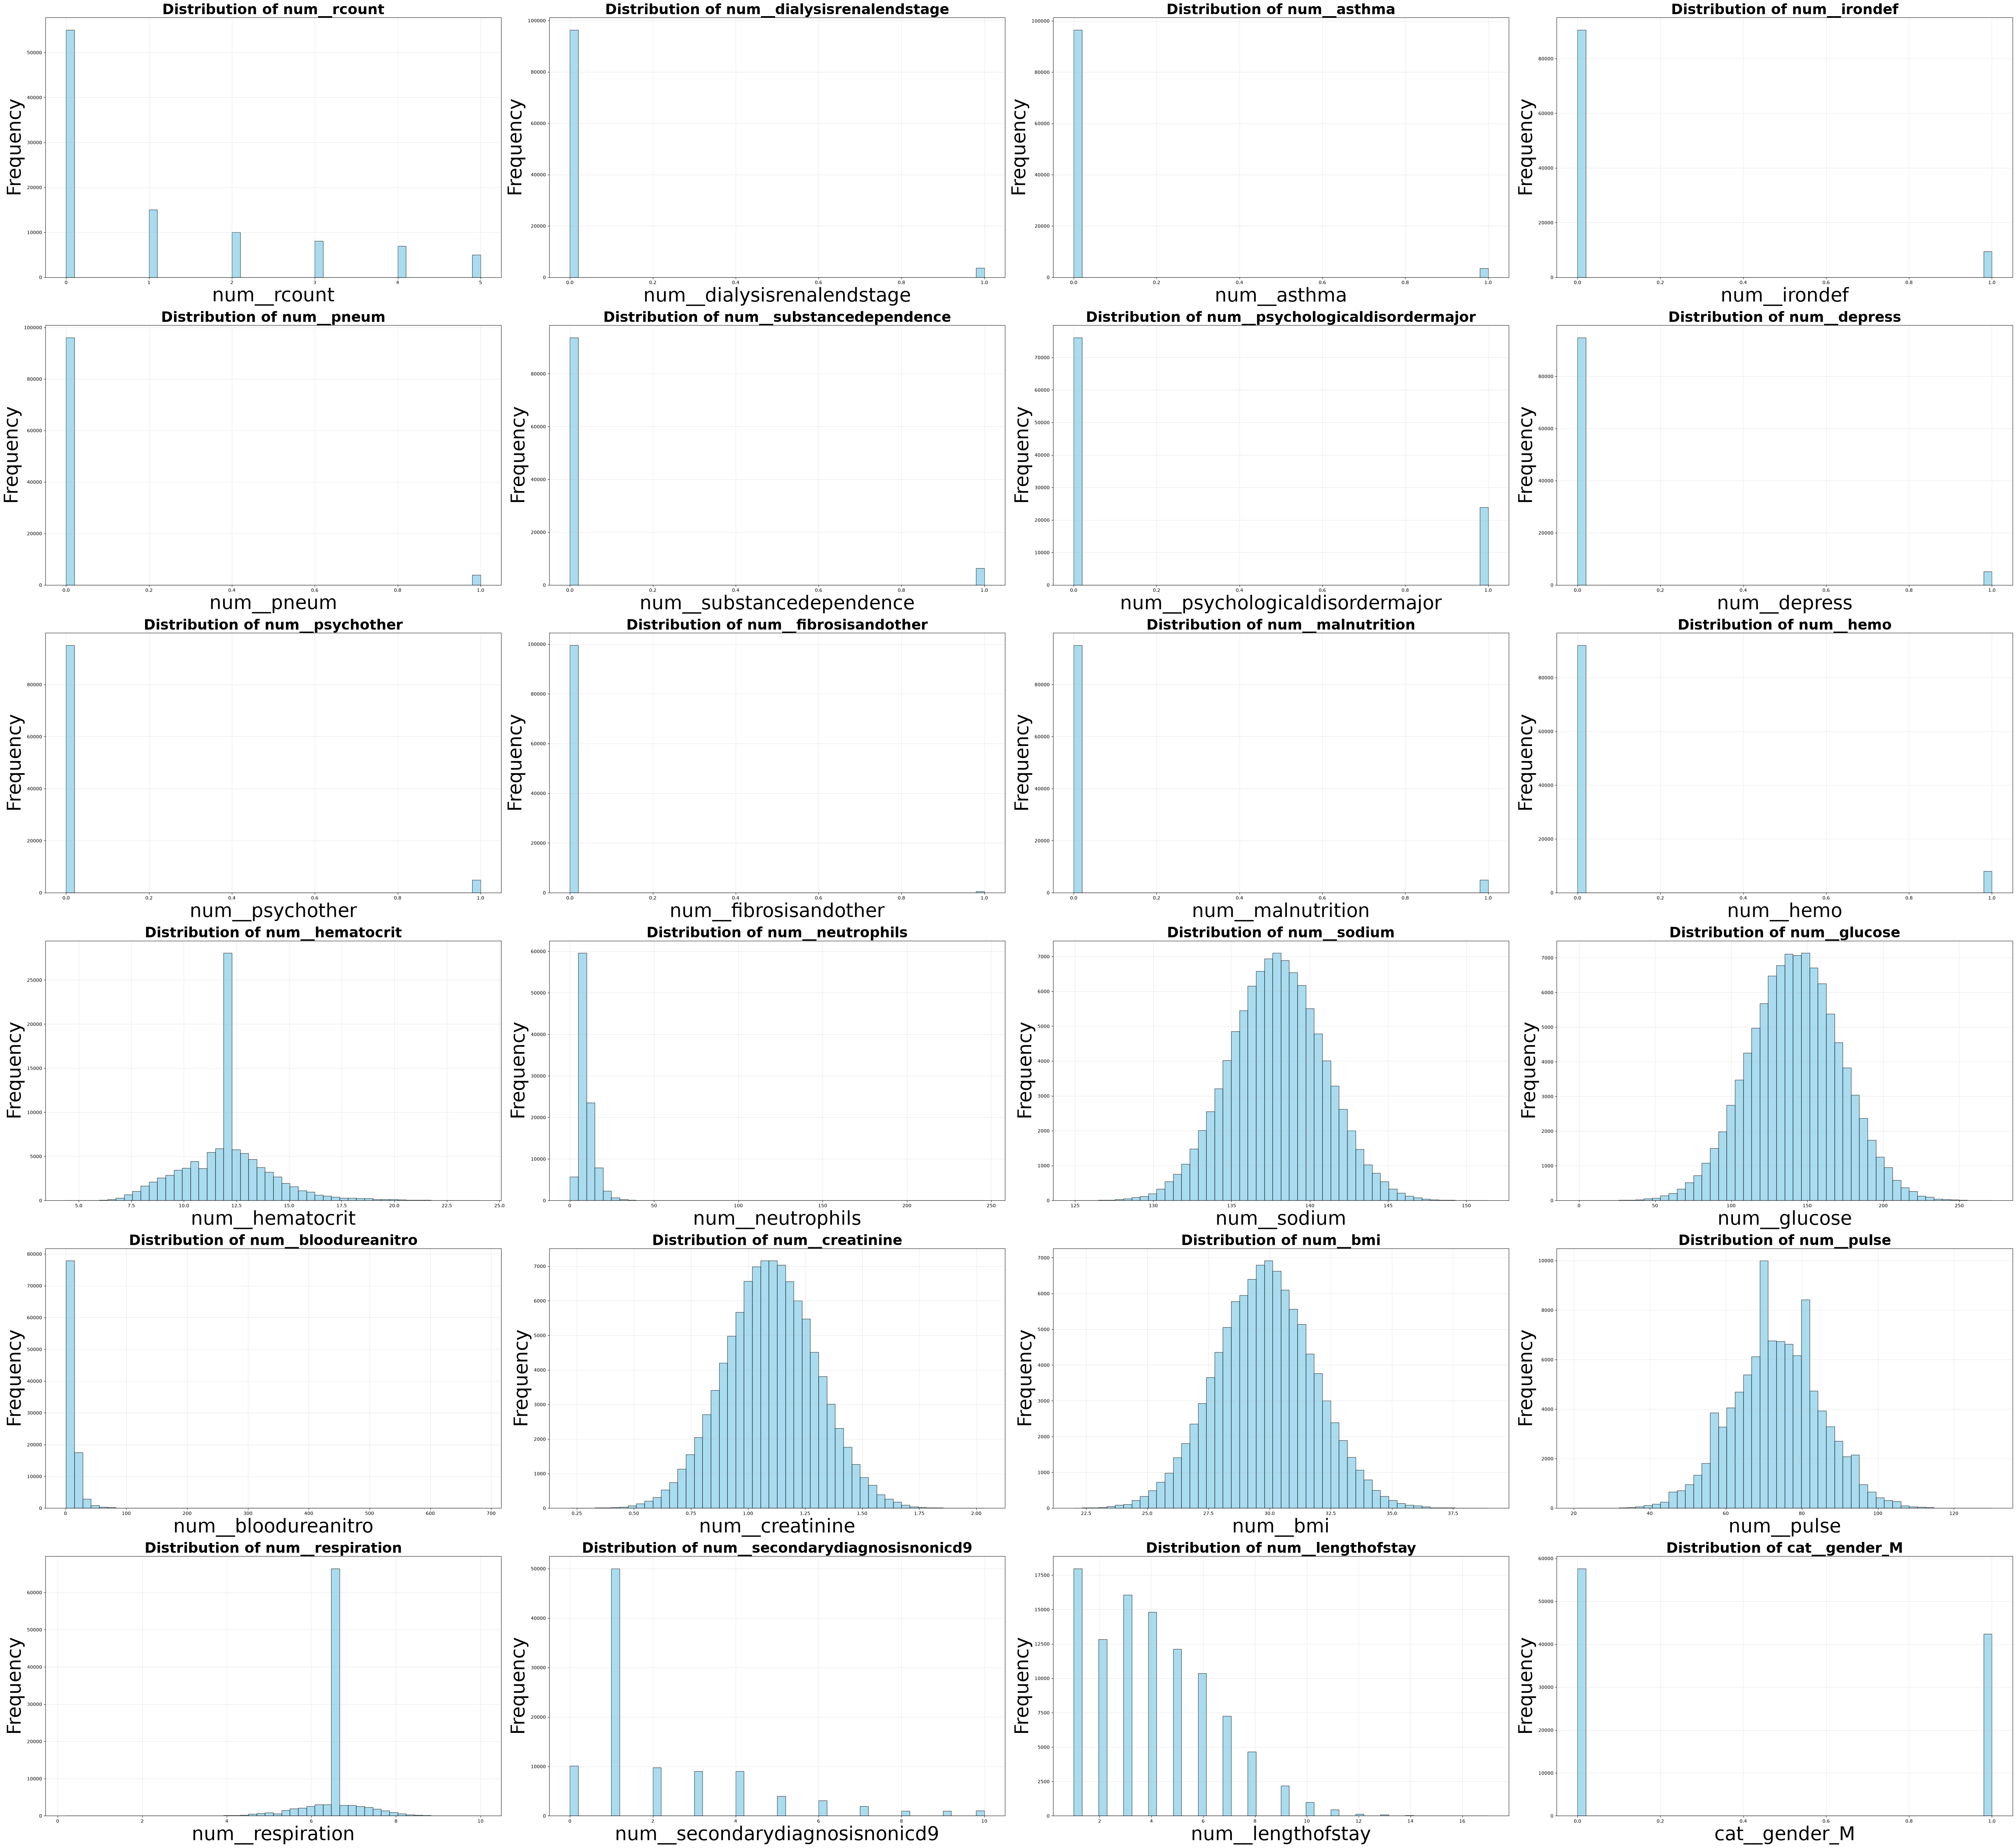

In [9]:
# Distribution visualizations
fig, axes = plt.subplots(6, 4, figsize=(60, 55))
axes = axes.ravel()

for idx, col in enumerate(df_imputed.columns):
    axes[idx].hist(df_imputed[col], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {col}', fontsize=30, fontweight='bold')
    axes[idx].set_xlabel(col, fontsize=40)
    axes[idx].set_ylabel('Frequency', fontsize=40)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 🗺️ Geographic Visualization



## 📊 Correlation Analysis

Understanding feature correlations helps us:
- Identify the most important features
- Detect multicollinearity
- Guide feature engineering

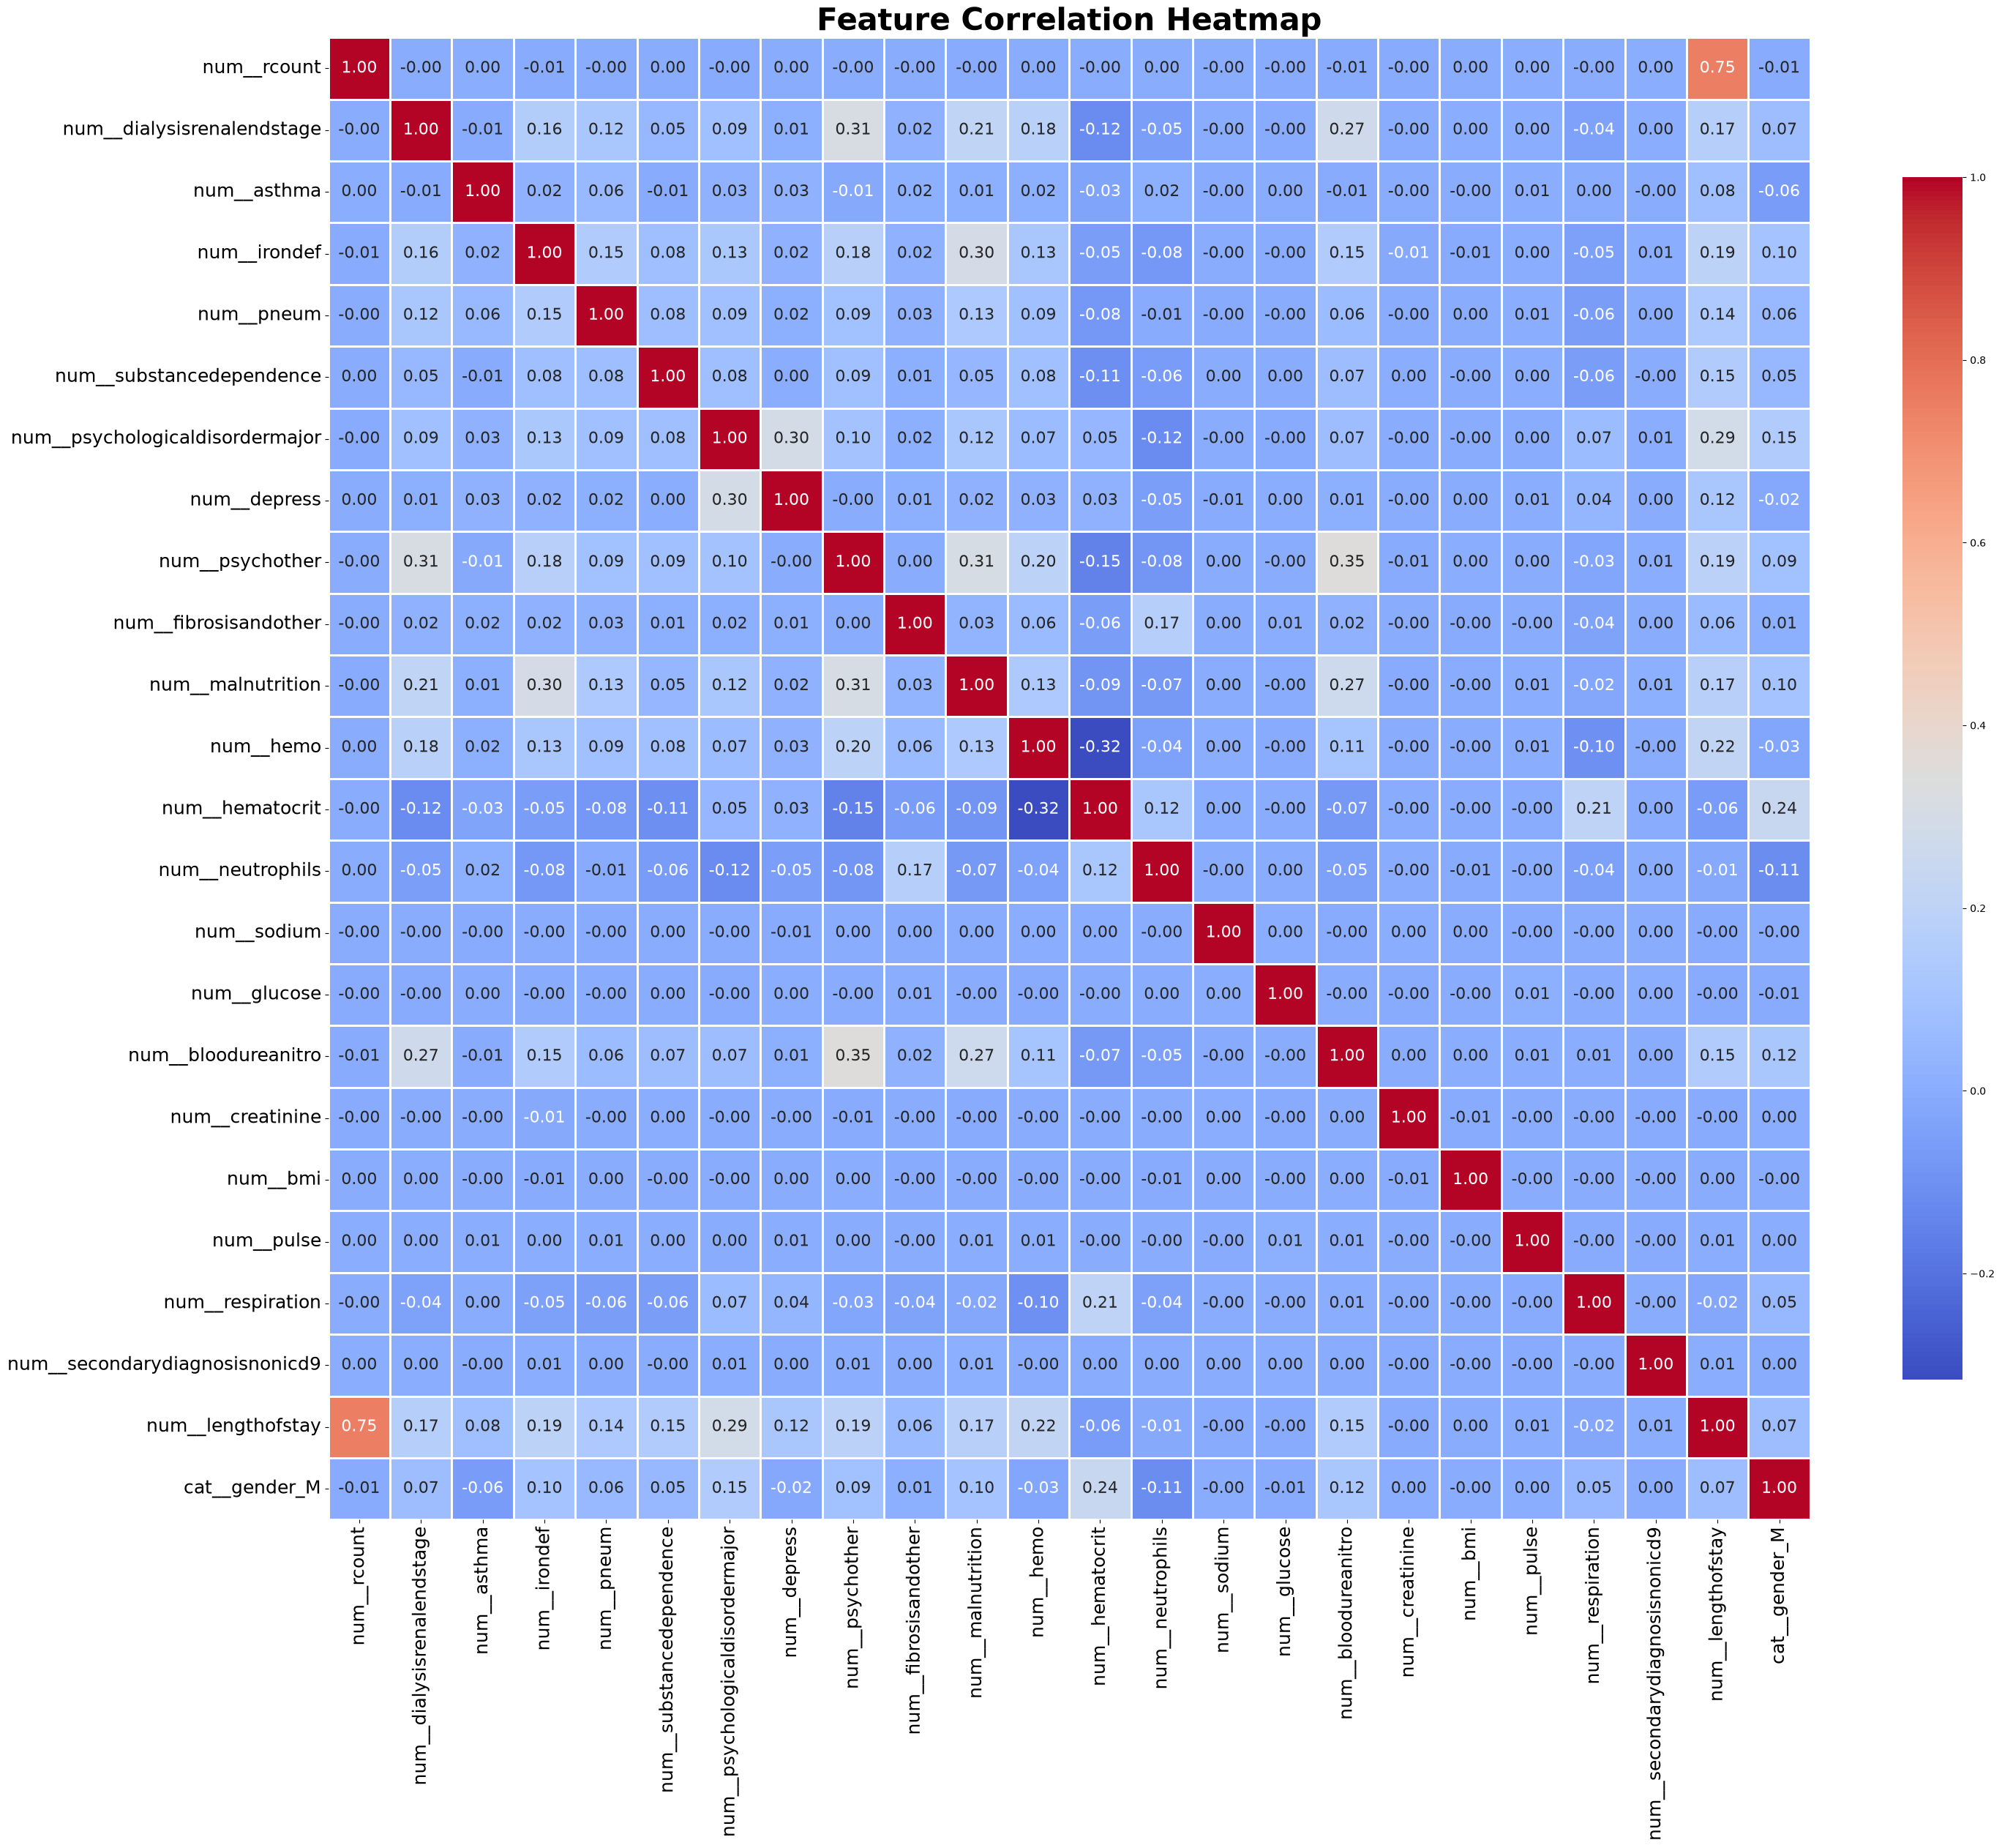


🎯 FEATURES RANKED BY CORRELATION WITH lengthofstay
num__rcount       0.7495
num__psychologicaldisordermajor   0.2867
num__hemo         0.2177
num__irondef      0.1938
num__psychother   0.1917
num__malnutrition   0.1744
num__dialysisrenalendstage   0.1697
num__bloodureanitro   0.1483
num__substancedependence   0.1479
num__pneum        0.1355
num__depress      0.1214
num__asthma       0.0820
cat__gender_M     0.0696
num__fibrosisandother   0.0621
num__pulse        0.0067
num__secondarydiagnosisnonicd9   0.0065
num__bmi          0.0002
num__glucose     -0.0034
num__sodium      -0.0035
num__creatinine  -0.0040
num__neutrophils  -0.0107
num__respiration  -0.0223
num__hematocrit  -0.0640


In [10]:
import seaborn as sns

# Correlation matrix
correlation_matrix = df_imputed.corr()

plt.figure(figsize=(30, 25))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},annot_kws={"size": 16})
plt.title('Feature Correlation Heatmap', fontsize=30, fontweight='bold')
plt.xticks(fontsize=18, rotation=90)
plt.yticks(fontsize=18, rotation=0)

plt.tight_layout()
plt.show()

# Feature importance ranking
print("\n" + "=" * 70)
print("🎯 FEATURES RANKED BY CORRELATION WITH lengthofstay")
print("=" * 70)
correlations = correlation_matrix['num__lengthofstay'].drop('num__lengthofstay').sort_values(ascending=False)
for feature, corr in correlations.items():
    print(f"{feature:<15} {corr:>8.4f}")

# 🧠 Pipeline 


# Specify the target

In [12]:
# Create DataFrame
X = df_imputed.drop(columns=["num__lengthofstay"])
Y = df_imputed["num__lengthofstay"] # Target v
feature_names = X.columns

print(f"\n✅ Dataset loaded successfully!")
print(f"Shape: {df_imputed.shape}")
print(f"Target Name:{Y.name}")
print("feature ")
print(f"Features:{feature_names}")
print(f"\nFirst 5 rows:")
X.head(2)



✅ Dataset loaded successfully!
Shape: (100000, 24)
Target Name:num__lengthofstay
feature 
Features:Index(['num__rcount', 'num__dialysisrenalendstage', 'num__asthma',
       'num__irondef', 'num__pneum', 'num__substancedependence',
       'num__psychologicaldisordermajor', 'num__depress', 'num__psychother',
       'num__fibrosisandother', 'num__malnutrition', 'num__hemo',
       'num__hematocrit', 'num__neutrophils', 'num__sodium', 'num__glucose',
       'num__bloodureanitro', 'num__creatinine', 'num__bmi', 'num__pulse',
       'num__respiration', 'num__secondarydiagnosisnonicd9', 'cat__gender_M'],
      dtype='str')

First 5 rows:


,num__rcount,num__dialysisrenalendstage,num__asthma,num__irondef,num__pneum,num__substancedependence,num__psychologicaldisordermajor,num__depress,num__psychother,num__fibrosisandother,...,num__neutrophils,num__sodium,num__glucose,num__bloodureanitro,num__creatinine,num__bmi,num__pulse,num__respiration,num__secondarydiagnosisnonicd9,cat__gender_M
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,14.2,140.361132,192.476918,12.0,1.390722,30.432418,96.0,6.5,4.0,0.0
1,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.1,136.731692,94.078507,8.0,0.943164,28.460516,61.0,6.5,1.0,0.0


# Check for outliers

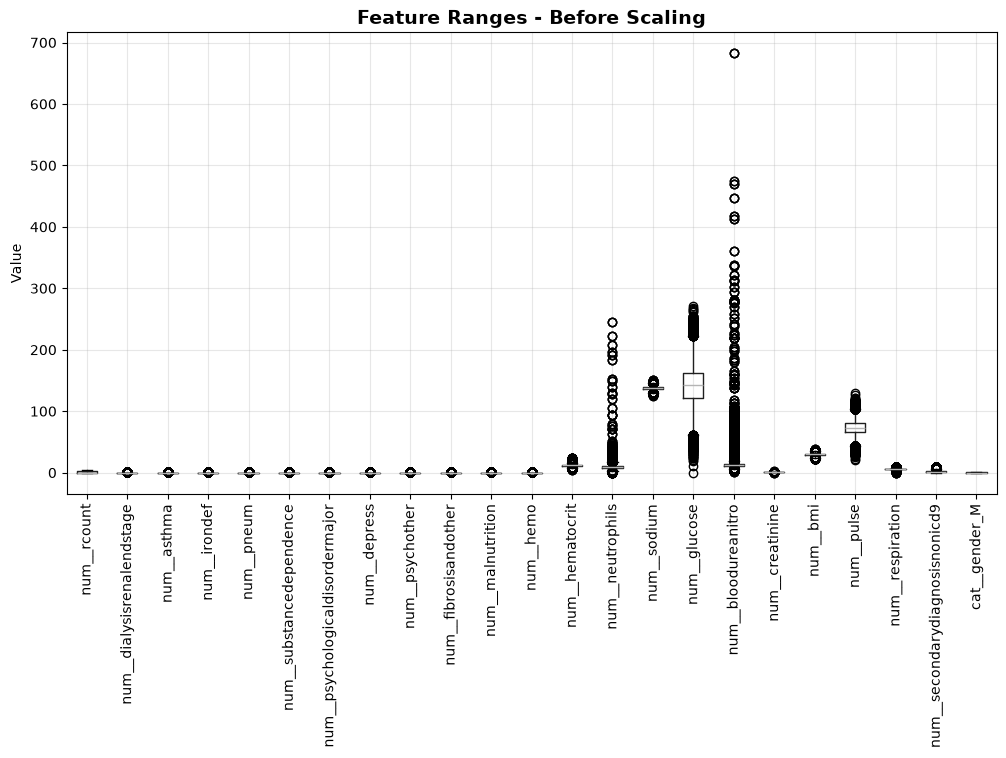

In [13]:
# Visualization:


# Before scaling
X.boxplot(figsize=(12, 6))
plt.title('Feature Ranges - Before Scaling', fontsize=14, fontweight='bold')
plt.ylabel('Value')
plt.xticks( rotation=90)
plt.grid(True, alpha=0.3)
plt.show()


# First Step: Advanced Feature Engineering

## comorb_count

### Definition:
'comorb_count': Comorbidity Count is the number of comorbid condition recorded for each patient. A comorbidity is any additional medical condition a patient has besides the main reason for admission.

### Calculation 
it is the sum of the 11 (0/1) diagnosis columns:
(num__dialysisrenalendstage +.....+....+...................+ num__hemo)


In [14]:

# NEW: Advanced Feature Engineering Class
class AdvancedFeatureEngineer:
    """Advanced feature engineering using domain knowledge"""
    
    def __init__(self):
        self.feature_names = []
    
    def fit(self, X, Y=None):
        return self  # No fitting needed for this transformer
    
    def transform(self, X):
        #X_eng = X.copy()
        X_eng = np.asarray(X, dtype=float).copy()
        # comorb_count: comorbidity count (the sum of other dises)
        X_eng = np.column_stack([
            X_eng,
            # comord_count
            np.sum(X_eng[:, 1:12], axis=1)
            
        
        ])
        
        # Update feature names for interpretability
        self.feature_names = list(feature_names) + ["comorb_count"]
        
        
        
        return X_eng

    def fit_transform(self, X, Y=None):
        """Mimics sklearn's fit_transform"""
        self.fit(X, Y)
        return self.transform(X)
    
    def get_feature_names(self):
        return self.feature_names



# Test our feature engineering
engineer = AdvancedFeatureEngineer()
X_engineered = engineer.fit_transform(X)

print(f"\n🎯 FEATURE ENGINEERING COMPLETE!")
print(f"• Original features: {X.shape[1]} (from previous work)")
print(f"• Engineered features: {X_engineered.shape[1]} (NEW!)")
print(f"• New features created: {engineer.feature_names[-1:]}")



🎯 FEATURE ENGINEERING COMPLETE!
• Original features: 23 (from previous work)
• Engineered features: 24 (NEW!)
• New features created: ['comorb_count']



## 🧭 Outlier Handling with IQR — Making the Data More Robust

---


### 🧮 IQR Outlier Detection Logic

For each feature:

1. Calculate **Q1 (25th percentile)** and **Q3 (75th percentile)**.
2. Compute **IQR = Q3 − Q1**.
3. Define:
   $$
   \text{Lower Bound} = Q1 - 1.5 \times IQR
   \quad
   \text{Upper Bound} = Q3 + 1.5 \times IQR
   $$
4. Clip any values outside this range to make the distribution **more stable**.

✅ **Why this matters:**

* Stabilizes scaling
* Reduces the influence of extreme values
* Keeps the data intact (no row deletion)
* Makes the pipeline more production-ready



In [15]:
from sklearn.base import BaseEstimator, TransformerMixin

# NEW: Outlier Handler for Robust Models
class OutlierHandler(BaseEstimator, TransformerMixin):
    """Handle outliers using IQR method - More robust than simple scaling"""
    
    def __init__(self, factor=1.5):
        self.factor = factor
        self.lower_bounds_ = None
        self.upper_bounds_ = None
    
    def fit(self, X, y=None):
        self.lower_bounds_ = []
        self.upper_bounds_ = []
        
        # Calculate IQR bounds for each feature
        for i in range(X.shape[1]):
            Q1 = np.percentile(X[:, i], 25)  # 25th percentile
            Q3 = np.percentile(X[:, i], 75)  # 75th percentile  
            IQR = Q3 - Q1  # Interquartile Range
            self.lower_bounds_.append(Q1 - self.factor * IQR)
            self.upper_bounds_.append(Q3 + self.factor * IQR)
        
        return self
    
    def transform(self, X):
        X_transformed = X.copy()
        # Clip values to IQR bounds
        for i in range(X.shape[1]):
            lower = self.lower_bounds_[i]
            upper = self.upper_bounds_[i]
            X_transformed[:, i] = np.clip(X_transformed[:, i], lower, upper)
        
        return X_transformed

## 🏗️ Building the Final Preprocessing Pipeline


---

## 🚀 Why a Unified Pipeline Matters

✅ Ensures **clean, reproducible transformations**
✅ Keeps preprocessing **modular and maintainable**
✅ Integrates seamlessly with model training & cross-validation
✅ Allows us to **deploy the same pipeline** in production (no data leakage)

---

## 🧪 Let’s Build It

We’ll combine all steps into a single `Pipeline` object:


In [16]:

# Create comprehensive preprocessing pipeline
preprocessor = Pipeline([
    ('feature_engineer', AdvancedFeatureEngineer()),  # Our new features
    ('outlier_handler', OutlierHandler(factor=1.5)),  # Handle outliers
    ('scaler', RobustScaler())  # Robust to outliers (better than StandardScaler)
])

# Apply preprocessing pipeline
print("🔄 Applying preprocessing pipeline...")
X_processed = preprocessor.fit_transform(X, Y)

print("✅ ADVANCED PREPROCESSING PIPELINE BUILT!")
print(f"📊 Processed data shape: {X_processed.shape}")
print(f"🎯 All feature names: {preprocessor.named_steps['feature_engineer'].get_feature_names()}")

🔄 Applying preprocessing pipeline...
✅ ADVANCED PREPROCESSING PIPELINE BUILT!
📊 Processed data shape: (100000, 24)
🎯 All feature names: ['num__rcount', 'num__dialysisrenalendstage', 'num__asthma', 'num__irondef', 'num__pneum', 'num__substancedependence', 'num__psychologicaldisordermajor', 'num__depress', 'num__psychother', 'num__fibrosisandother', 'num__malnutrition', 'num__hemo', 'num__hematocrit', 'num__neutrophils', 'num__sodium', 'num__glucose', 'num__bloodureanitro', 'num__creatinine', 'num__bmi', 'num__pulse', 'num__respiration', 'num__secondarydiagnosisnonicd9', 'cat__gender_M', 'comorb_count']


# After scaling 

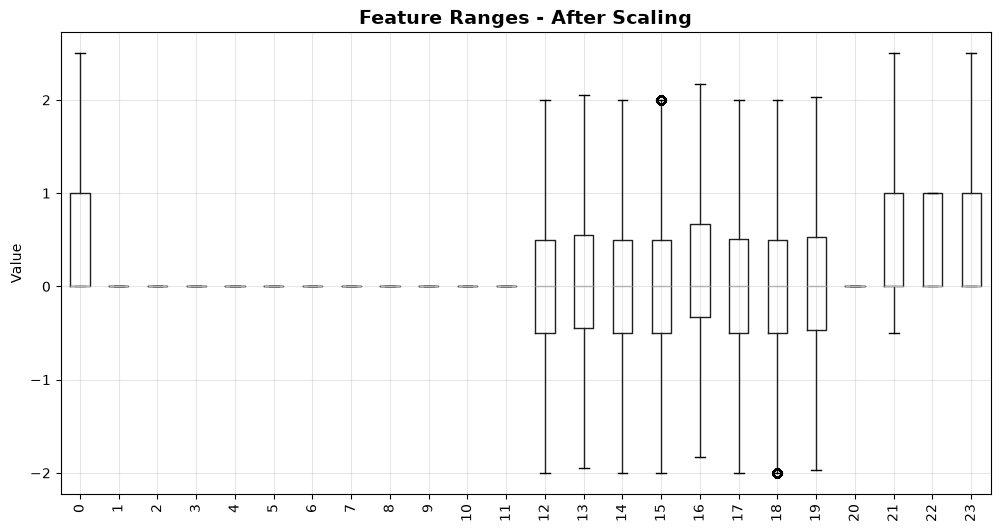

In [17]:
df_X_processed = pd.DataFrame(X_processed)
df_X_processed.boxplot(figsize=(12, 6))
plt.title('Feature Ranges - After Scaling', fontsize=14, fontweight='bold')
plt.ylabel('Value')
plt.xticks( rotation=90)
plt.grid(True, alpha=0.3)
plt.show()



---

## 🧪 Smarter Data Splitting: Adding a Validation Set

---

## 🆕 Better Approach: Train / Validation / Test Split

To solve these issues, we **add a validation set** between training and testing:

* 🧠 **Train set** → Used to train the model.
* 🧪 **Validation set** → Used to tune hyperparameters, early stopping, and model selection.
* 🧭 **Test set** → Kept **completely unseen** until the very end for final evaluation.

This separation ensures:

* ✅ Cleaner model evaluation
* ✅ More reliable hyperparameter tuning
* ✅ Reduced overfitting to the test set
* ✅ More realistic production performance estimation

---


## 🧱 Implementation:


In [18]:
# Improved data splitting with validation set
X_temp, X_test, y_temp, y_test = train_test_split(
    X_processed, Y, test_size=config.TEST_SIZE, random_state=config.RANDOM_STATE
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=config.VAL_SIZE, random_state=config.RANDOM_STATE
)


print(f"📊 DATA SPLITS (IMPROVED from previous notebook):")
print(f"• Training: {X_train.shape[0]:,} samples (model learning)")
print(f"• Validation: {X_val.shape[0]:,} samples (hyperparameter tuning)") 
print(f"• Test: {X_test.shape[0]:,} samples (final evaluation - NEVER TOUCHED until end)")

📊 DATA SPLITS (IMPROVED from previous notebook):
• Training: 64,000 samples (model learning)
• Validation: 16,000 samples (hyperparameter tuning)
• Test: 20,000 samples (final evaluation - NEVER TOUCHED until end)




---

## 🆕 Introducing Advanced Models

We now upgrade our model set to include a **diverse mix of linear, regularized, tree-based, and ensemble learners**:

| Model Name                     | Type                  | Why We Add It 🧭                                                    |
| ------------------------------ | --------------------- | ------------------------------------------------------------------- |
| `LinearRegression`             | Linear Baseline       | A clean baseline — interpretable and fast.                          |
| `Ridge Regression`             | Regularized Linear    | Controls overfitting with L2 regularization.                        |
| `Lasso Regression`             | Regularized Linear    | Performs **feature selection** via L1 penalty.                      |
| `ElasticNet` 🆕                | Hybrid Regularization | Combines L1 + L2 — more flexible for correlated features.           |
| `RandomForestRegressor` 🆕     | Tree Ensemble         | Handles nonlinearities & interactions without feature engineering.  |
| `GradientBoostingRegressor` 🆕 | Boosting Ensemble     | Learns sequentially, improving weak learners over time.             |
| `Support Vector Regression` 🆕 | Kernel Method         | Captures complex relationships using kernel tricks.                 |
| `VotingRegressor` 🆕           | Ensemble Strategy     | Combines multiple models for **stronger, more stable performance**. |

---

## ⚡ Why This Matters in Production

✅ **Model diversity** improves your chances of finding a high-performing model.
✅ **Regularized models** give stability and interpretability.
✅ **Ensemble methods** usually outperform single models in complex tasks.
✅ **Nonlinear models** can capture patterns linear models miss.

This setup also makes it easy to:

* 📊 Compare models consistently
* 🧪 Run hyperparameter tuning later
* 🧠 Blend models into a **final ensemble**

---

## 🧱 Implementation



In [19]:
# define advanced models - Expanded from previous work
advanced_models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(random_state=config.RANDOM_STATE),
    'Lasso Regression': Lasso(random_state=config.RANDOM_STATE),
    'ElasticNet': ElasticNet(random_state=config.RANDOM_STATE),  # NEW: Combines L1 + L2
    #'poly': PolynomialFeatures(degree=3, include_bias=False),
    'Random Forest': RandomForestRegressor(random_state=config.RANDOM_STATE, n_jobs=config.N_JOBS),
    'Gradient Boosting': GradientBoostingRegressor(random_state=config.RANDOM_STATE),  # NEW: Sequential learning
    'Support Vector Regression': SVR(),  # NEW: Different approach
}

# NEW: Voting Ensemble - Combines multiple models
voting_ensemble = VotingRegressor([
    ('ridge', Ridge(random_state=config.RANDOM_STATE)),
    ('rf', RandomForestRegressor(random_state=config.RANDOM_STATE, n_jobs=config.N_JOBS)),
    ('gb', GradientBoostingRegressor(random_state=config.RANDOM_STATE))
])

advanced_models['Voting Ensemble'] = voting_ensemble

print(f"\n🎯 MODEL PORTFOLIO ({len(advanced_models)} models):")


🎯 MODEL PORTFOLIO (8 models):




### 🚀 Full Advanced Model Evaluation (All-in-One)

This implementation runs the **entire model evaluation workflow in a single function**:

1. **Train the model** → records training time.
2. **Evaluate on training and validation sets** → computes RMSE, R², MAE, and overfitting gap.
3. **Cross-validation** → estimates model stability and performance variability across folds.
4. **MLflow logging** → automatically logs hyperparameters, metrics, and saves the model artifact.
5. **Loop over multiple models** → trains, evaluates, and tracks all models in one go, reporting **validation R², cross-validation mean ± std, and overfitting warnings**.



In [20]:
def evaluate_model_advanced(model, X_train, X_val, y_train, y_val, model_name):
    """Comprehensive model evaluation with MLflow tracking"""
    
    # Start MLflow run for experiment tracking
    with mlflow.start_run(run_name=model_name):
        # Train model with timing
        start_time = time.time()
        model.fit(X_train, y_train)
        training_time = time.time() - start_time
        
        # Predictions on both sets
        y_train_pred = model.predict(X_train)
        y_val_pred = model.predict(X_val)
        
        # Calculate comprehensive metrics
        metrics = {
            'train_rmse': np.sqrt(mean_squared_error(y_train, y_train_pred)),
            'val_rmse': np.sqrt(mean_squared_error(y_val, y_val_pred)),
            'train_r2': r2_score(y_train, y_train_pred),
            'val_r2': r2_score(y_val, y_val_pred),
            'train_mae': mean_absolute_error(y_train, y_train_pred),
            'val_mae': mean_absolute_error(y_val, y_val_pred),
            'training_time': training_time,
            'overfitting_gap': r2_score(y_train, y_train_pred) - r2_score(y_val, y_val_pred)
        }
        
        # AUTOMATIC TRACKING with MLflow
        mlflow.log_params(model.get_params())  # Log hyperparameters
        mlflow.log_metrics({k: v for k, v in metrics.items() if k != 'training_time'})
        mlflow.sklearn.log_model(model, "model" , skops_trusted_types=["sklearn.tree._tree.Tree","sklearn.utils._bunch.Bunch"])  # Save model artifact
        
        # Cross-validation for robust performance estimate
        cv_scores = cross_val_score(model, X_train, y_train, 
                                  cv=config.CV_FOLDS, scoring='r2', n_jobs=config.N_JOBS)
        metrics['cv_r2_mean'] = cv_scores.mean()
        metrics['cv_r2_std'] = cv_scores.std()
        
        mlflow.log_metrics({
            'cv_r2_mean': metrics['cv_r2_mean'],
            'cv_r2_std': metrics['cv_r2_std']
        })
        
        return metrics, model

print("🚀 STARTING ADVANCED MODEL EVALUATION...")
print("Each model is being trained, evaluated, and tracked in MLflow")

results = {}
trained_models = {}

for name, model in advanced_models.items():
    print(f"\n🔧 Training {name}...")
    metrics, trained_model = evaluate_model_advanced(
        model, X_train, X_val, y_train, y_val, name
    )
    results[name] = metrics
    trained_models[name] = trained_model
    
    # Progress reporting
    overfitting_indicator = "⚠️" if metrics['overfitting_gap'] > 0.1 else "✅"
    print(f"✅ {name:20} | Val R²: {metrics['val_r2']:.4f} | "
          f"CV R²: {metrics['cv_r2_mean']:.4f} ± {metrics['cv_r2_std']:.4f} "
          f"{overfitting_indicator}")

print(f"\n📈 All models trained and tracked in MLflow!")
print(f"💡 Check MLflow UI: mlflow ui --backend-store-uri {config.EXPERIMENT_DIR}")

🚀 STARTING ADVANCED MODEL EVALUATION...
Each model is being trained, evaluated, and tracked in MLflow

🔧 Training Linear Regression...


2026/10/09 09:13:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/10/09 09:13:26 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\hp\projects\SAIR
2026/10/09 09:13:34 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\hp\projects\SAIR
2026/10/09 09:13:34 INFO mlflow.utils.environment: Detected uv project at c:\Users\hp\projects\SAIR. Attempting to export requirements via 'uv export'.
2026/10/09 09:13:36 INFO mlflow.utils.uv_utils: Exported 103 dependencies via uv
2026/10/09 09:13:36 INFO mlflow.utils.environment: Successfully exported 103 requirements from uv project. Skipping package capture based inference.
2026/10/09 09:13:46 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


✅ Linear Regression    | Val R²: 0.7469 | CV R²: 0.7473 ± 0.0036 ✅

🔧 Training Ridge Regression...


2026/10/09 09:14:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/10/09 09:14:11 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\hp\projects\SAIR
2026/10/09 09:14:14 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\hp\projects\SAIR
2026/10/09 09:14:14 INFO mlflow.utils.environment: Detected uv project at c:\Users\hp\projects\SAIR. Attempting to export requirements via 'uv export'.
2026/10/09 09:14:14 INFO mlflow.utils.uv_utils: Exported 103 dependencies via uv
2026/10/09 09:14:14 INFO mlflow.utils.environment: Successfully exported 103 requirements from uv project. Skipping package capture based inference.
2026/10/09 09:14:15 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


✅ Ridge Regression     | Val R²: 0.7469 | CV R²: 0.7473 ± 0.0036 ✅

🔧 Training Lasso Regression...


...

✅ Gradient Boosting    | Val R²: 0.9301 | CV R²: 0.9301 ± 0.0008 ✅

🔧 Training Support Vector Regression...


2026/10/09 09:53:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/10/09 09:53:04 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\hp\projects\SAIR
2026/10/09 09:53:05 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\hp\projects\SAIR
2026/10/09 09:53:05 INFO mlflow.utils.environment: Detected uv project at c:\Users\hp\projects\SAIR. Attempting to export requirements via 'uv export'.
2026/10/09 09:53:05 INFO mlflow.utils.uv_utils: Exported 103 dependencies via uv
2026/10/09 09:53:05 INFO mlflow.utils.environment: Successfully exported 103 requirements from uv project. Skipping package capture based inference.
2026/10/09 09:53:05 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


✅ Support Vector Regression | Val R²: 0.8898 | CV R²: 0.8895 ± 0.0014 ✅

🔧 Training Voting Ensemble...


2026/10/09 10:29:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/10/09 10:29:11 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\hp\projects\SAIR
2026/10/09 10:29:20 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\hp\projects\SAIR
2026/10/09 10:29:20 INFO mlflow.utils.environment: Detected uv project at c:\Users\hp\projects\SAIR. Attempting to export requirements via 'uv export'.
2026/10/09 10:29:22 INFO mlflow.utils.uv_utils: Exported 103 dependencies via uv
2026/10/09 10:29:22 INFO mlflow.utils.environment: Successfully exported 103 requirements from uv project. Skipping package capture based inference.
2026/10/09 10:29:24 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


✅ Voting Ensemble      | Val R²: 0.8986 | CV R²: 0.8983 ± 0.0018 ✅

📈 All models trained and tracked in MLflow!
💡 Check MLflow UI: mlflow ui --backend-store-uri experiments


## 📊 Model Comparison & Visualization

In this section, we summarize and visualize the performance of all trained models. 

- First, we convert the `results` dictionary into a readable table.  
- Then, we create simple plots for key metrics to help interpret model performance:

1. **Validation R²** → Higher is better ✅  
2. **Validation RMSE** → Lower is better ✅  
3. **Overfitting Gap** → Closer to 0 is better ⚖️  

These visualizations make it easy for both technical and non-technical users to compare models at a glance.

📊 Model comparison table:


,Model,val_r2,val_rmse,val_mae,overfitting_gap,cv_r2_mean
0,Linear Regression,0.746926,1.189098,0.895894,0.000435,0.747275
1,Ridge Regression,0.746926,1.189098,0.895894,0.000434,0.747275
2,Lasso Regression,0.261317,2.031528,1.655985,-0.003147,0.258153
3,ElasticNet,0.402480,1.827132,1.481730,-0.001580,0.400892
4,Random Forest,0.913745,0.694202,0.438184,0.074337,0.912559
5,Gradient Boosting,0.930110,0.624885,0.447443,0.001649,0.930134
6,Support Vector Regression,0.889848,0.784496,0.544954,0.011388,0.889453
7,Voting Ensemble,0.898614,0.752633,0.542026,0.031652,0.898298


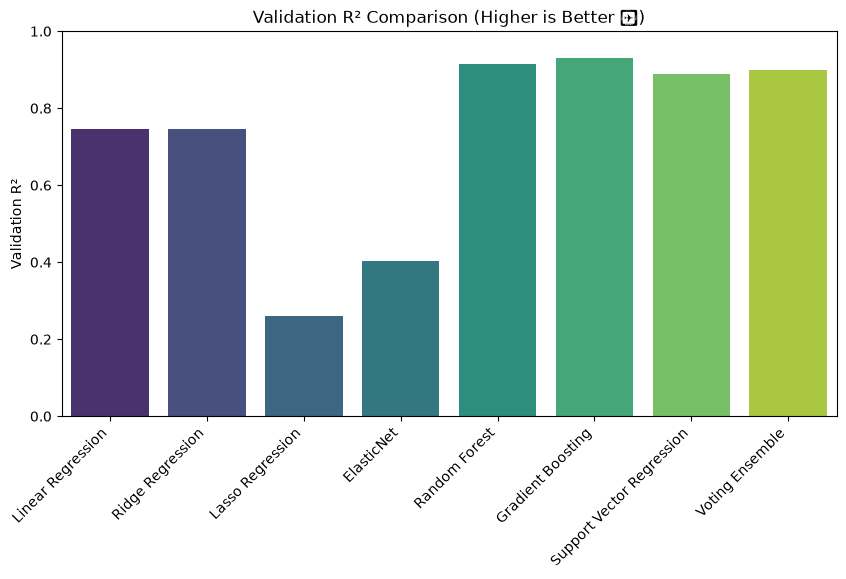

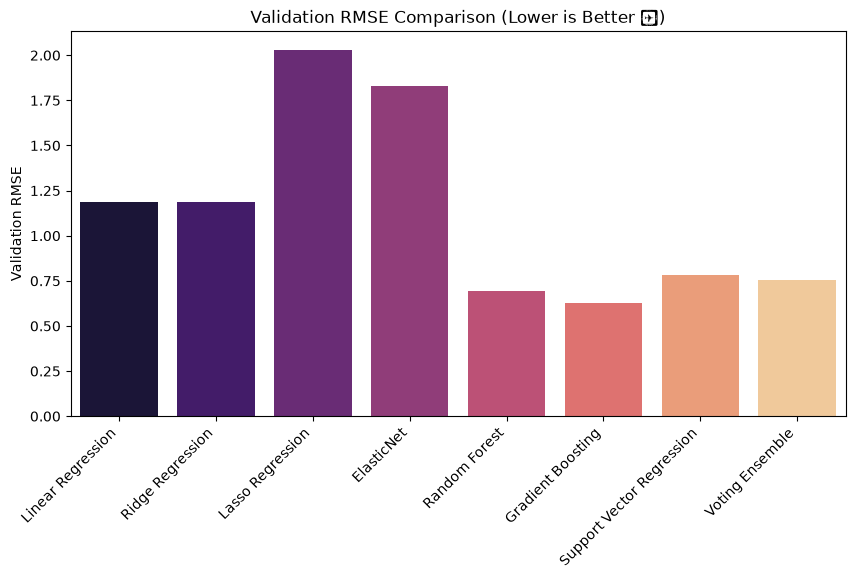

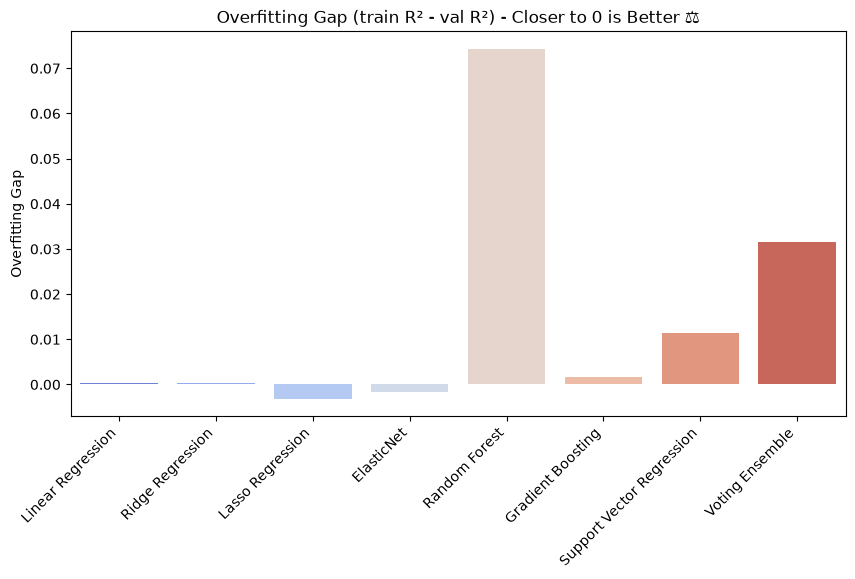

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ===========================
# 1️⃣ Convert results dict to DataFrame
# ===========================
metrics_df = pd.DataFrame(results).T  # transpose so models are rows
metrics_df = metrics_df[['val_r2', 'val_rmse', 'val_mae', 'overfitting_gap', 'cv_r2_mean']]
metrics_df = metrics_df.reset_index().rename(columns={'index': 'Model'})

print("📊 Model comparison table:")
display(metrics_df)

# ===========================
# 2️⃣ Plot Validation R² (Higher is better)
# ===========================
plt.figure(figsize=(10, 5))
sns.barplot(data=metrics_df, x='Model', y='val_r2', palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Validation R² Comparison (Higher is Better ✅)')
plt.ylabel('Validation R²')
plt.xlabel('')
plt.ylim(0, 1)
plt.show()

# ===========================
# 3️⃣ Plot Validation RMSE (Lower is better)
# ===========================
plt.figure(figsize=(10, 5))
sns.barplot(data=metrics_df, x='Model', y='val_rmse', palette='magma')
plt.xticks(rotation=45, ha='right')
plt.title('Validation RMSE Comparison (Lower is Better ✅)')
plt.ylabel('Validation RMSE')
plt.xlabel('')
plt.show()

# ===========================
# 4️⃣ Plot Overfitting Gap (Closer to 0 is better)
# ===========================
plt.figure(figsize=(10, 5))
sns.barplot(data=metrics_df, x='Model', y='overfitting_gap', palette='coolwarm')
plt.xticks(rotation=45, ha='right')
plt.title('Overfitting Gap (train R² - val R²) - Closer to 0 is Better ⚖️')
plt.ylabel('Overfitting Gap')
plt.xlabel('')
plt.show()


## 📊 Advanced Model Comparison Visualization 
Read and explore this on your own time , its more advance and speclialized version of the previous one

📈 ADVANCED MODEL COMPARISON

🏆 MODEL PERFORMANCE RANKING
Model                     Val R²   CV R²        Overfitting  Time (s)  
--------------------------------------------------------------------------------
Gradient Boosting          0.9301  0.9301 ± 0.0008   ✅  0.0016     49.70
Random Forest              0.9137  0.9126 ± 0.0010   ✅  0.0743     44.97
Voting Ensemble            0.8986  0.8983 ± 0.0018   ✅  0.0317     62.61
Support Vector Regression  0.8898  0.8895 ± 0.0014   ✅  0.0114    954.04
Ridge Regression           0.7469  0.7473 ± 0.0036   ✅  0.0004      1.90
Linear Regression          0.7469  0.7473 ± 0.0036   ✅  0.0004      0.56
ElasticNet                 0.4025  0.4009 ± 0.0021   ✅ -0.0016      0.06
Lasso Regression           0.2613  0.2582 ± 0.0015   ✅ -0.0031      1.47


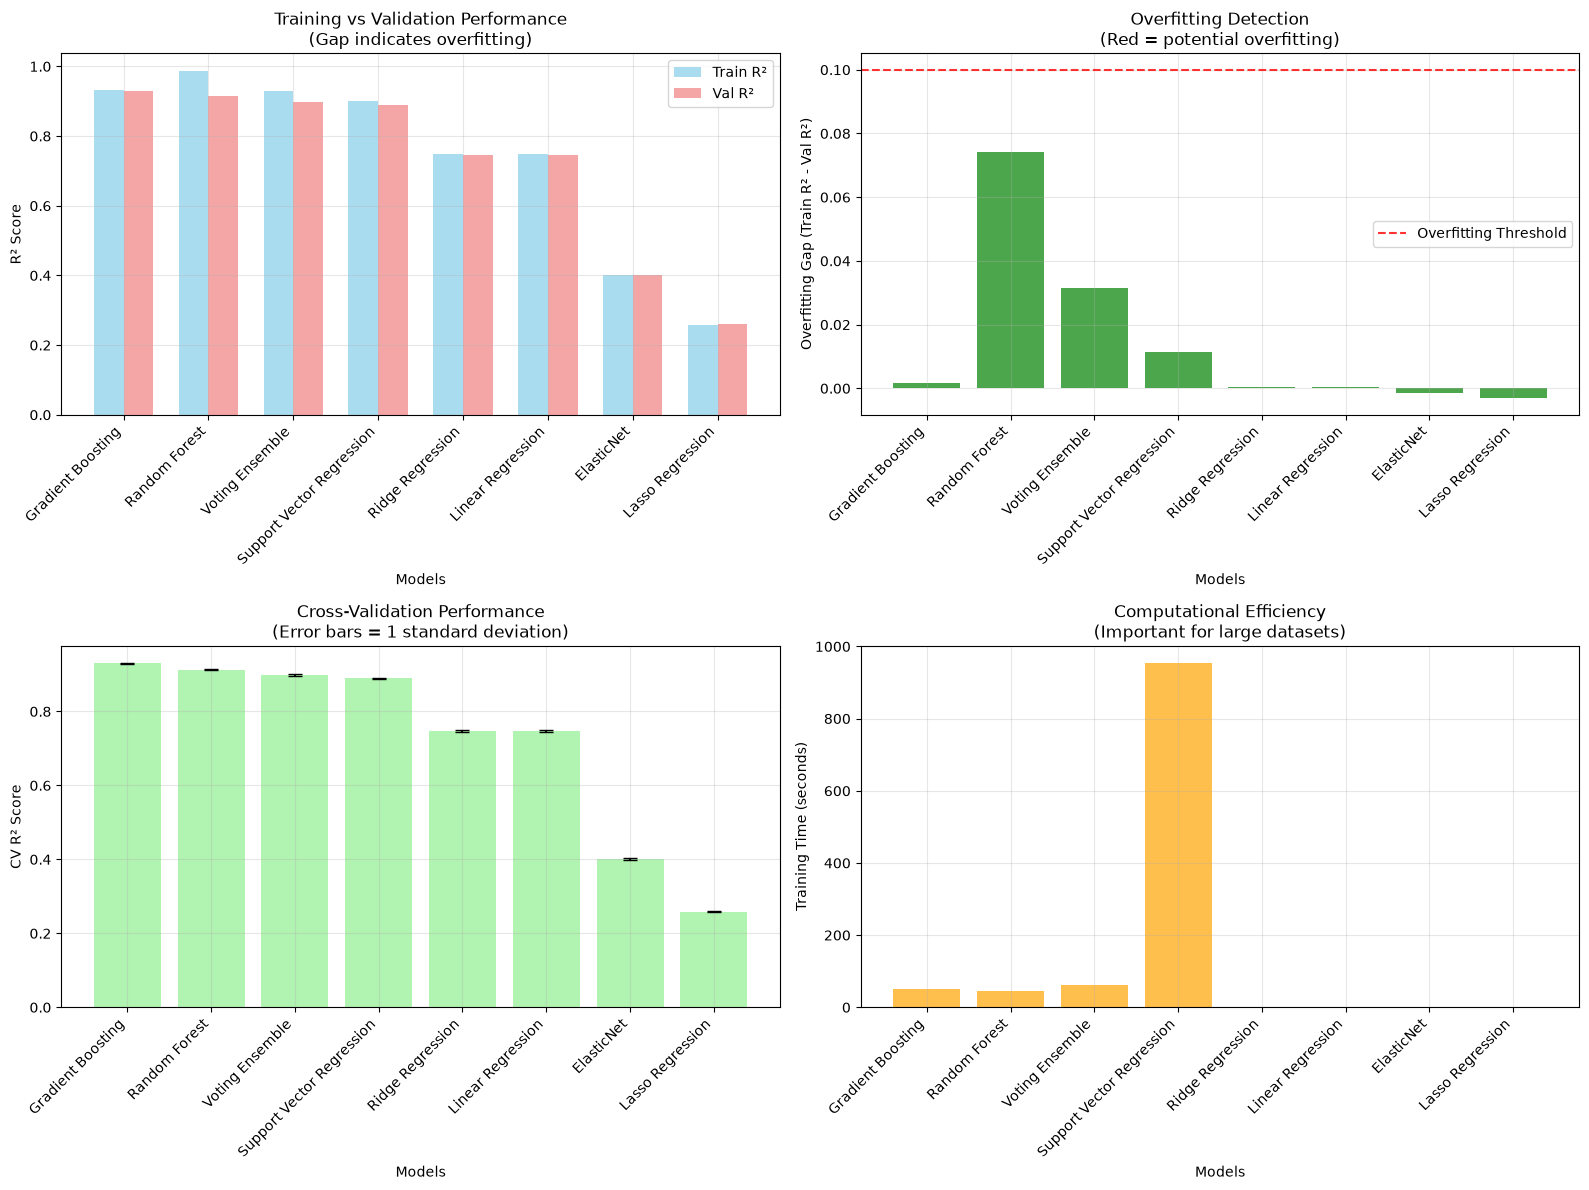


🎯 BEST MODEL SELECTED: Gradient Boosting
📊 Validation R²: 0.9301
🔍 CV R²: 0.9301 ± 0.0008

💡 INTERPRETATION GUIDE:
• Good: High R², small train-val gap, stable CV, reasonable training time
• Overfitting: Large gap between train and validation performance
• Unstable: Large CV standard deviation
• Best choice: Balances performance, stability, and efficiency


In [23]:
# 📈 CELL 7: Advanced Model Comparison Visualization
print("📈 ADVANCED MODEL COMPARISON")

# Create comprehensive results dataframe
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('val_r2', ascending=False)

print("\n" + "=" * 80)
print("🏆 MODEL PERFORMANCE RANKING")
print("=" * 80)
print(f"{'Model':<25} {'Val R²':<8} {'CV R²':<12} {'Overfitting':<12} {'Time (s)':<10}")
print("-" * 80)

for model_name in results_df.index:
    row = results_df.loc[model_name]
    overfitting_indicator = "⚠️" if row['overfitting_gap'] > 0.1 else "✅"
    print(f"{model_name:<25} {row['val_r2']:>7.4f} {row['cv_r2_mean']:>7.4f} ± {row['cv_r2_std']:>5.4f} "
          f"{overfitting_indicator:>3} {row['overfitting_gap']:>7.4f} {row['training_time']:>9.2f}")

# Comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. R² Comparison
models_ordered = results_df.index
val_r2 = [results[model]['val_r2'] for model in models_ordered]
train_r2 = [results[model]['train_r2'] for model in models_ordered]

x = np.arange(len(models_ordered))
width = 0.35

axes[0, 0].bar(x - width/2, train_r2, width, label='Train R²', alpha=0.7, color='skyblue')
axes[0, 0].bar(x + width/2, val_r2, width, label='Val R²', alpha=0.7, color='lightcoral')
axes[0, 0].set_xlabel('Models')
axes[0, 0].set_ylabel('R² Score')
axes[0, 0].set_title('Training vs Validation Performance\n(Gap indicates overfitting)')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(models_ordered, rotation=45, ha='right')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Overfitting Analysis
overfitting_gaps = [results[model]['overfitting_gap'] for model in models_ordered]
colors = ['red' if gap > 0.1 else 'green' for gap in overfitting_gaps]
axes[0, 1].bar(models_ordered, overfitting_gaps, color=colors, alpha=0.7)
axes[0, 1].axhline(y=0.1, color='red', linestyle='--', alpha=0.8, label='Overfitting Threshold')
axes[0, 1].set_xlabel('Models')
axes[0, 1].set_ylabel('Overfitting Gap (Train R² - Val R²)')
axes[0, 1].set_title('Overfitting Detection\n(Red = potential overfitting)')
axes[0, 1].set_xticklabels(models_ordered, rotation=45, ha='right')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Cross-Validation Stability
cv_means = [results[model]['cv_r2_mean'] for model in models_ordered]
cv_stds = [results[model]['cv_r2_std'] for model in models_ordered]
axes[1, 0].bar(models_ordered, cv_means, yerr=cv_stds, capsize=5, alpha=0.7, color='lightgreen')
axes[1, 0].set_xlabel('Models')
axes[1, 0].set_ylabel('CV R² Score')
axes[1, 0].set_title('Cross-Validation Performance\n(Error bars = 1 standard deviation)')
axes[1, 0].set_xticklabels(models_ordered, rotation=45, ha='right')
axes[1, 0].grid(True, alpha=0.3)

# 4. Computational Efficiency
training_times = [results[model]['training_time'] for model in models_ordered]
axes[1, 1].bar(models_ordered, training_times, alpha=0.7, color='orange')
axes[1, 1].set_xlabel('Models')
axes[1, 1].set_ylabel('Training Time (seconds)')
axes[1, 1].set_title('Computational Efficiency\n(Important for large datasets)')
axes[1, 1].set_xticklabels(models_ordered, rotation=45, ha='right')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Select best model
best_model_name = results_df.index[0]
best_model = trained_models[best_model_name]
print(f"\n🎯 BEST MODEL SELECTED: {best_model_name}")
print(f"📊 Validation R²: {results_df.iloc[0]['val_r2']:.4f}")
print(f"🔍 CV R²: {results_df.iloc[0]['cv_r2_mean']:.4f} ± {results_df.iloc[0]['cv_r2_std']:.4f}")

print("\n💡 INTERPRETATION GUIDE:")
print("• Good: High R², small train-val gap, stable CV, reasonable training time")
print("• Overfitting: Large gap between train and validation performance") 
print("• Unstable: Large CV standard deviation")
print("• Best choice: Balances performance, stability, and efficiency")

## ⚙️ Advanced Hyperparameter Optimization

Machine learning models have **hyperparameters**—settings that control how the model learns.  
Choosing the right hyperparameters can dramatically improve performance.

- **Default parameters** are rarely optimal.  
- **Systematic search** (like `RandomizedSearchCV`) explores different combinations efficiently.  
- **MLflow tracking** logs all experiments, making it easy to compare results.  

In this section, we will tune hyperparameters for several models:
- Random Forest
- Gradient Boosting


> 🎯 Goal: Find the best configurations that maximize model performance while preventing overfitting.

In [24]:
# Define comprehensive hyperparameter grids
param_grids = {
    'Random Forest': {
        'n_estimators': [50, 100, ],  # Number of trees
        'max_depth': [None, 10,  30],       # Tree depth
        'min_samples_split': [2, 5],       # Minimum samples to split
        'min_samples_leaf': [ 2, 4],         # Minimum samples per leaf
        'max_features': ['auto', 'sqrt', 'log2']  # Features to consider for splits
    },
    
    'Gradient Boosting': {
        'n_estimators': [50, 100, ],        # Number of boosting stages
        'learning_rate': [0.01,  0.1, 0.2],  # Step size shrinkage
        'max_depth': [3, 4,  6],             # Maximum depth per tree
        'min_samples_split': [2,  10],       # Minimum samples to split
        'subsample': [0.8,  1.0]           # Fraction of samples for fitting
    },
    
    
    
   
} 

## 📝 Steps: Hyperparameter Optimization

1. **Initialize storage**  
   - `tuned_models` will store the best model for each algorithm.  
   - `optimization_results` will store the best score and parameters for each model.

2. **Loop over each model**  
   - Models: Random Forest, Gradient Boosting, Ridge Regression, Voting Ensemble.  

3. **Start MLflow tracking**  
   - Each model tuning run is logged with `mlflow.start_run(run_name=model_name_tuned)`.

4. **Run RandomizedSearchCV**  
   - Tries `n_iter=20` random combinations from the model’s hyperparameter grid.  
   - Uses cross-validation (`cv=config.CV_FOLDS`) to estimate performance.  
   - Scores models using R² (`scoring='r2'`).

5. **Fit the search**  
   - Fits the model on the training data and finds the best hyperparameters.

6. **Store best results**  
   - Best model saved in `tuned_models`.  
   - Best score and parameters saved in `optimization_results`.

7. **Log everything to MLflow**  
   - Hyperparameters, best cross-validation score, and the tuned model artifact.

8. **Print summary**  
   - Shows best CV R² and the parameters found for each model.

> 🎯 Goal: Automatically find the best hyperparameter settings to maximize model performance while keeping tracking and reproducibility simple.

In [25]:

# Perform hyperparameter optimization
print("🎯 STARTING HYPERPARAMETER OPTIMIZATION...")
tuned_models = {}
optimization_results = {}

for model_name in ['Random Forest', 'Gradient Boosting']:
    print(f"\n🔧 Tuning {model_name}...")
    
    with mlflow.start_run(run_name=f"{model_name}_tuned"):
        # Use RandomizedSearchCV for efficient optimization
        search = RandomizedSearchCV(
            advanced_models[model_name],
            param_grids[model_name],
            n_iter=5,  # Try 20 random combinations (efficient!)
            cv=config.CV_FOLDS,
            scoring='r2',
            n_jobs=config.N_JOBS,
            random_state=config.RANDOM_STATE,
            verbose=1
        )
        
        # Perform the search
        search.fit(X_train, y_train)
        
        # Store results
        tuned_models[model_name] = search.best_estimator_
        optimization_results[model_name] = {
            'best_score': search.best_score_,
            'best_params': search.best_params_,
            'best_estimator': search.best_estimator_
        }
        
        # Log to MLflow
        mlflow.log_params(search.best_params_)
        mlflow.log_metric('best_cv_score', search.best_score_)
        mlflow.sklearn.log_model(search.best_estimator_, "tuned_model" , skops_trusted_types=["sklearn.tree._tree.Tree","sklearn.utils._bunch.Bunch"])
        
        print(f"✅ {model_name:20} | Best CV R²: {search.best_score_:.4f}")
        print(f"   Best parameters found: {search.best_params_}")

print(f"\n🎉 HYPERPARAMETER OPTIMIZATION COMPLETE!")
print(f"💡 All tuned models saved in MLflow for comparison")

🎯 STARTING HYPERPARAMETER OPTIMIZATION...

🔧 Tuning Random Forest...
Fitting 5 folds for each of 5 candidates, totalling 25 fits


2026/10/09 10:37:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/10/09 10:37:21 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\hp\projects\SAIR
2026/10/09 10:37:25 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\hp\projects\SAIR
2026/10/09 10:37:25 INFO mlflow.utils.environment: Detected uv project at c:\Users\hp\projects\SAIR. Attempting to export requirements via 'uv export'.
2026/10/09 10:37:27 INFO mlflow.utils.uv_utils: Exported 103 dependencies via uv
2026/10/09 10:37:27 INFO mlflow.utils.environment: Successfully exported 103 requirements from uv project. Skipping package capture based inference.
2026/10/09 10:37:30 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


✅ Random Forest        | Best CV R²: 0.8960
   Best parameters found: {'n_estimators': 50, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None}

🔧 Tuning Gradient Boosting...
Fitting 5 folds for each of 5 candidates, totalling 25 fits


2026/10/09 10:41:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/10/09 10:41:11 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\hp\projects\SAIR
2026/10/09 10:41:12 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\hp\projects\SAIR
2026/10/09 10:41:12 INFO mlflow.utils.environment: Detected uv project at c:\Users\hp\projects\SAIR. Attempting to export requirements via 'uv export'.
2026/10/09 10:41:12 INFO mlflow.utils.uv_utils: Exported 103 dependencies via uv
2026/10/09 10:41:12 INFO mlflow.utils.environment: Successfully exported 103 requirements from uv project. Skipping package capture based inference.
2026/10/09 10:41:13 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


✅ Gradient Boosting    | Best CV R²: 0.9399
   Best parameters found: {'subsample': 0.8, 'n_estimators': 100, 'min_samples_split': 10, 'max_depth': 4, 'learning_rate': 0.2}

🎉 HYPERPARAMETER OPTIMIZATION COMPLETE!
💡 All tuned models saved in MLflow for comparison


📊 Tuned Models Performance:


,Model,Best CV R²
0,Random Forest,0.896040
1,Gradient Boosting,0.939896


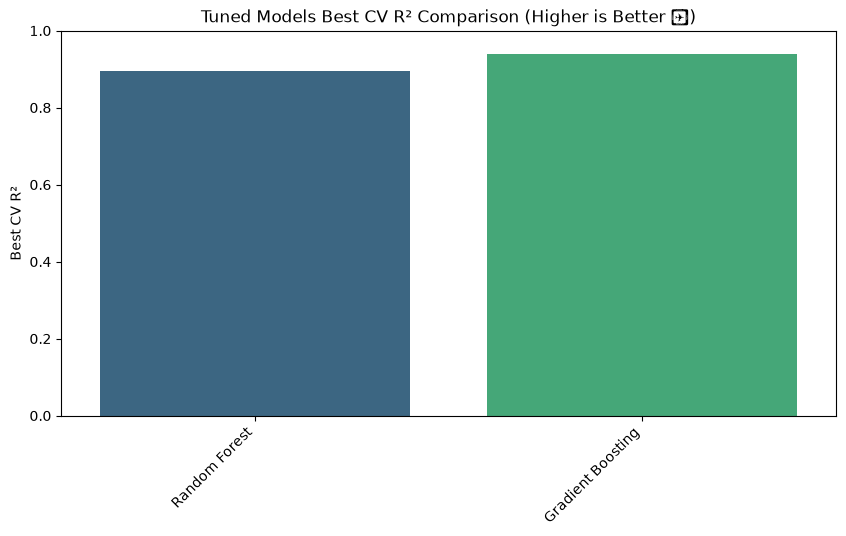

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ===========================
# 1️⃣ Convert optimization results to DataFrame
# ===========================
tuned_metrics_df = pd.DataFrame.from_dict({
    model: {
        'Best CV R²': optimization_results[model]['best_score']
    } for model in optimization_results
}, orient='index').reset_index().rename(columns={'index': 'Model'})

print("📊 Tuned Models Performance:")
display(tuned_metrics_df)

# ===========================
# 2️⃣ Plot Best CV R² (Higher is better)
# ===========================
plt.figure(figsize=(10,5))
sns.barplot(data=tuned_metrics_df, x='Model', y='Best CV R²', palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Tuned Models Best CV R² Comparison (Higher is Better ✅)')
plt.ylabel('Best CV R²')
plt.xlabel('')
plt.ylim(0,1)
plt.show()


# A more sophisticated version of the previous visualization

Model                Untuned R²   Tuned R²     Improvement 
------------------------------------------------------------
Random Forest            0.9137     0.9009 📉  -0.0129
Gradient Boosting        0.9301     0.9411 📈   0.0110


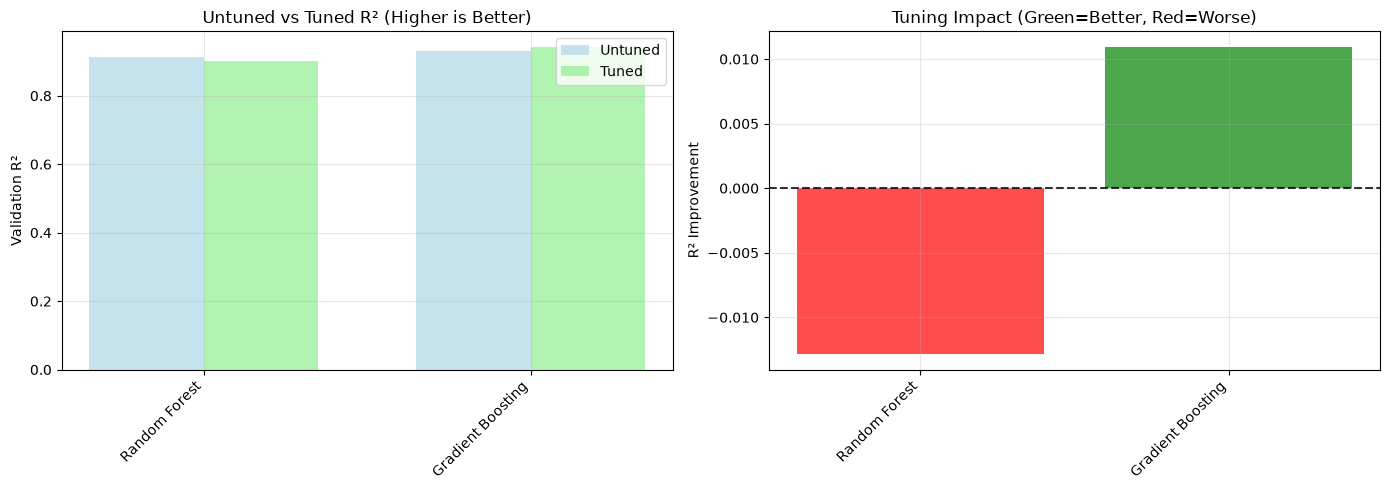


🏆 BEST TUNED MODEL: Gradient Boosting
📊 Validation R²: 0.9411
📈 Improvement over untuned: +0.0110


In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

# ===========================
# 1️⃣ Evaluate tuned models on validation set
# ===========================
tuned_results = {}
for model_name, tuned_model in tuned_models.items():
    y_val_pred = tuned_model.predict(X_val)
    val_r2 = r2_score(y_val, y_val_pred)
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    improvement = val_r2 - results[model_name]['val_r2']  # vs untuned
    
    tuned_results[model_name] = {
        'val_r2': val_r2,
        'val_rmse': val_rmse,
        'improvement': improvement
    }

# ===========================
# 2️⃣ Print simple comparison table
# ===========================
print(f"{'Model':<20} {'Untuned R²':<12} {'Tuned R²':<12} {'Improvement':<12}")
print("-" * 60)
for model_name, res in tuned_results.items():
    untuned_r2 = results[model_name]['val_r2']
    tuned_r2 = res['val_r2']
    improvement = res['improvement']
    icon = "📈" if improvement > 0 else "📉" if improvement < 0 else "➡️"
    print(f"{model_name:<20} {untuned_r2:>10.4f} {tuned_r2:>10.4f} {icon} {improvement:>8.4f}")

# ===========================
# 3️⃣ Plot Tuned vs Untuned R²
# ===========================
models = list(tuned_results.keys())
untuned_r2 = [results[m]['val_r2'] for m in models]
tuned_r2 = [tuned_results[m]['val_r2'] for m in models]
improvement = [tuned_results[m]['improvement'] for m in models]

x = np.arange(len(models))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# R² comparison
axes[0].bar(x - width/2, untuned_r2, width, label='Untuned', alpha=0.7, color='lightblue')
axes[0].bar(x + width/2, tuned_r2, width, label='Tuned', alpha=0.7, color='lightgreen')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=45, ha='right')
axes[0].set_ylabel('Validation R²')
axes[0].set_title('Untuned vs Tuned R² (Higher is Better)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Improvement plot
colors = ['green' if i>0 else 'red' for i in improvement]
axes[1].bar(models, improvement, color=colors, alpha=0.7)
axes[1].axhline(0, color='black', linestyle='--', alpha=0.8)
axes[1].set_ylabel('R² Improvement')
axes[1].set_title('Tuning Impact (Green=Better, Red=Worse)')
axes[1].set_xticklabels(models, rotation=45, ha='right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ===========================
# 4️⃣ Best tuned model
# ===========================
best_model_name = max(tuned_results, key=lambda m: tuned_results[m]['val_r2'])
print(f"\n🏆 BEST TUNED MODEL: {best_model_name}")
print(f"📊 Validation R²: {tuned_results[best_model_name]['val_r2']:.4f}")
print(f"📈 Improvement over untuned: +{tuned_results[best_model_name]['improvement']:.4f}")


# ✅ Final Test Set Evaluation
To ensure our selected best model is not overfitting and truly generalizes,we perform a final evaluation on the held-out test set. 
This step provides an unbiased estimate of how the model will perform on unseen data, which is a standard and critical practice in machine learning before deploying a model to production.


In [28]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

best_tuned_model = tuned_models[best_model_name] # add this line 

# Predict on test set
y_test_pred = best_tuned_model.predict(X_test)

# Compute performance metrics
test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)

print(f"📊 Test R²: {test_r2:.4f}")
print(f"📊 Test RMSE: {test_rmse:.4f}")
print(f"📊 Test MAE: {test_mae:.4f}")


📊 Test R²: 0.9403
📊 Test RMSE: 0.5724
📊 Test MAE: 0.4160


# 🚀 Model Deployment Preparation
Now that we have selected the best tuned model and confirmed it generalizes well on the validation (and test) data, we can prepare it for deployment.

# This involves several important steps:
1️⃣ Identify the best model based on validation performance.

2️⃣ Version the model and save both the trained model and preprocessing pipeline.

3️⃣ Create a comprehensive model card containing metadata, performance metrics, data information, model configuration, preprocessing steps, and deployment instructions.

4️⃣ Save deployment requirements to ensure reproducibility in production.

These steps ensure that the model is production-ready and can be deployed (e.g., via Streamlit) in a consistent, versioned, and well-documented manner.


In [29]:
import os
import json
import joblib
from datetime import datetime
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# ===========================
# 0️⃣ Prepare feature names
# ===========================
# Works for both DataFrame and NumPy array
try:
    feature_names_all = list(X.columns)
except AttributeError:
    feature_names_all = [f"feature_{i}" for i in range(X.shape[1])]

# ===========================
# 1️⃣ Identify best tuned model
# ===========================
best_model_name = max(tuned_results, key=lambda m: tuned_results[m]['val_r2'])
best_tuned_model = tuned_models[best_model_name]

print(f"🏆 BEST TUNED MODEL: {best_model_name}")
print(f"📊 Validation R²: {tuned_results[best_model_name]['val_r2']:.4f}")
print(f"📈 Improvement over untuned: +{tuned_results[best_model_name]['improvement']:.4f}")

# ===========================
# 2️⃣ Evaluate on Test Set
# ===========================
y_test_pred = best_tuned_model.predict(X_test)
test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)

print(f"\n📊 Test Set Performance:")
print(f"R²: {test_r2:.4f} | RMSE: {test_rmse:.4f} | MAE: {test_mae:.4f}")

# ===========================
# 3️⃣ Versioning and saving
# ===========================
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_version = f"v1_{timestamp}"
model_save_dir = os.path.join(config.MODEL_DIR, model_version)
os.makedirs(model_save_dir, exist_ok=True)

# Save model
model_path = os.path.join(model_save_dir, 'best_model.pkl')
joblib.dump(best_tuned_model, model_path)
print(f"✅ Model saved: {model_path}")

# Save preprocessing pipeline
preprocessor_path = os.path.join(model_save_dir, 'preprocessor.pkl')
joblib.dump(preprocessor, preprocessor_path)
print(f"✅ Preprocessor saved: {preprocessor_path}")

# ===========================
# 4️⃣ Create model card
# ===========================
model_card = {
    'model_name': best_model_name,
    'model_version': model_version,
    'timestamp': timestamp,
    'dataset': 'California Housing',
    'target': 'House Price ($M)',
    
    'performance': {
        'test_r2': float(test_r2),
        'test_rmse': float(test_rmse),
        'test_mae': float(test_mae),
        'train_r2': float(results[best_model_name]['train_r2']),
        'val_r2': float(tuned_results[best_model_name]['val_r2']),
        'cv_r2_mean': float(results[best_model_name]['cv_r2_mean']),
        'cv_r2_std': float(results[best_model_name]['cv_r2_std']),
    },
    
    'data_info': {
        'total_samples': int(len(X)),
        'train_samples': int(len(X_train)),
        'val_samples': int(len(X_val)),
        'test_samples': int(len(X_test)),
        'n_features': X_test.shape[1],
        'feature_names': feature_names_all,
    },
    
    'model_config': {
        'model_class': best_model_name,
        'hyperparameters': dict(best_tuned_model.get_params()) 
            if hasattr(best_tuned_model, 'get_params') else {},
    },
    
    'preprocessing': {
        'steps': [
            'AdvancedFeatureEngineering (6 new features)',
            'OutlierHandling (IQR method)',
            'RobustScaler (outlier-resistant scaling)',
        ],
        'outlier_factor': 1.5,
    },
    
    'deployment': {
        'status': 'Ready for Production',
        'recommendations': [
            'Monitor prediction errors in production',
            'Retrain quarterly with new data',
            'Alert if RMSE exceeds $0.50M',
        ]
    }
}

card_path = os.path.join(model_save_dir, 'model_card.json')
with open(card_path, 'w') as f:
    json.dump(model_card, f, indent=2)
print(f"✅ Model card saved: {card_path}")

# ===========================
# 5️⃣ Deployment requirements
# ===========================
requirements = {
    'python': '3.8+',
    'packages': {
        'scikit-learn': '1.0+',
        'numpy': '1.20+',
        'pandas': '1.3+',
        'joblib': '1.0+',
    }
}

req_path = os.path.join(model_save_dir, 'requirements.json')
with open(req_path, 'w') as f:
    json.dump(requirements, f, indent=2)
print(f"✅ Deployment requirements saved: {req_path}")

# ===========================
# 6️⃣ Summary
# ===========================
print("\n💾 DEPLOYMENT PACKAGE READY")
print(f"Location: {model_save_dir}")


🏆 BEST TUNED MODEL: Gradient Boosting
📊 Validation R²: 0.9411
📈 Improvement over untuned: +0.0110

📊 Test Set Performance:
R²: 0.9403 | RMSE: 0.5724 | MAE: 0.4160
✅ Model saved: models\v1_20261009_104433\best_model.pkl
✅ Preprocessor saved: models\v1_20261009_104433\preprocessor.pkl
✅ Model card saved: models\v1_20261009_104433\model_card.json
✅ Deployment requirements saved: models\v1_20261009_104433\requirements.json

💾 DEPLOYMENT PACKAGE READY
Location: models\v1_20261009_104433


## 🚀 Final Step: Interactive Prediction UI with Streamlit

After completing model training, evaluation, versioning, and saving all artifacts (model, preprocessor, model card, and requirements), the **final step** is to create a **user-friendly interface** for making predictions in real time.


### Implementation

- The interactive UI is **already implemented** in this project as:

  1. **`app.py`**  
     - Main Streamlit script for the dashboard.  
     - Loads the latest model and preprocessor.  
     - Accepts user input via sliders, runs predictions, and displays results.

  2. **`utils.py`** *(optional helper module)*  
     - Contains reusable utility functions such as feature preprocessing, input validation, and prediction wrappers.  

